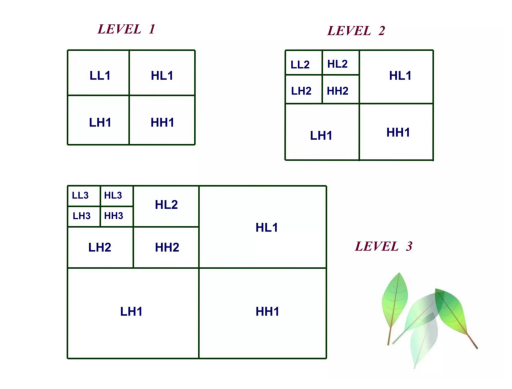

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pywt
import os
import glob
import itertools
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

# Hàm tính hash bằng Wavelet
def wavelet_hash_pywt(image, size=(64, 64), wavelet='haar'):
    #chuyển sang grayscale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    #resize(64, 64) và chuẩn hóa giá trị pixel về [0, 1]
    gray = cv2.resize(gray, size)
    gray = np.float32(gray) / 255.0
    #Biến đổi Wavelet Rời rạc (DWT) để lấy dải tần số thấp (LL)
    coeffs = pywt.wavedec2(gray, wavelet, level=1)
    LL, (LH, HL, HH) = coeffs 
    #Tạo hash từ LL
    avg = np.mean(LL)
    diff = LL > avg
    #Chuyển về dạng 1D
    return diff.flatten()
# Hàm so sánh hai hash và đếm số bit khác nhau
def get_hamming_distance(hash1, hash2):
    return np.count_nonzero(hash1 != hash2)
img_1= cv2.imread('../wavelet/dataset/wavelet.png')
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()


In [2]:
# Hàm nạp cặp ảnh và tên, kiểm tra tính hợp lệ
def load_pairs(pairs):
    valid_pairs = []

    for img1, img2, name1, name2 in pairs:
        if img1 is not None and img2 is not None:
            valid_pairs.append((img1, img2, name1, name2))
        else:
            print(f"Lỗi: Không đọc được ảnh {name1} hoặc {name2}")
    return valid_pairs

#Lấy dữ liệu từ thư mục
similar_folder = '../wavelet/dataset/similar'
different_folder = '../wavelet/dataset/different'

raw_similar = []    
raw_dissimilar = []

#Tạo cặp ảnh giống nhau
orig_name = "original.jpg"
orig_img = cv2.imread(f"{similar_folder}/{orig_name}")
#Tạo cặp ảnh giống nhau bằng cách kết hợp ảnh gốc với các ảnh tương tự trong thư mục
if orig_img is not None:
    sim_paths = glob.glob(f"{similar_folder}/*.jpg")
    for path in sim_paths:
        if orig_name not in path:
            aug_img = cv2.imread(path)
            aug_name = os.path.basename(path) 
            raw_similar.append((orig_img, aug_img, orig_name, aug_name))

# Tạo cặp ảnh khác nhau bằng cách kết hợp tất cả ảnh trong thư mục khác nhau với nhau
diff_paths = glob.glob(f"{different_folder}/*.jpg")
for path1, path2 in itertools.combinations(diff_paths, 2):
    img1 = cv2.imread(path1)
    img2 = cv2.imread(path2)
    name1 = os.path.basename(path1)
    name2 = os.path.basename(path2)
    raw_dissimilar.append((img1, img2, name1, name2))

# Gán biến
similar_pairs = load_pairs(raw_similar)
dissimilar_pairs = load_pairs(raw_dissimilar)
print(f"Đã nạp thành công: {len(similar_pairs)} cặp giống nhau và {len(dissimilar_pairs)} cặp khác nhau.")

Đã nạp thành công: 11 cặp giống nhau và 66 cặp khác nhau.


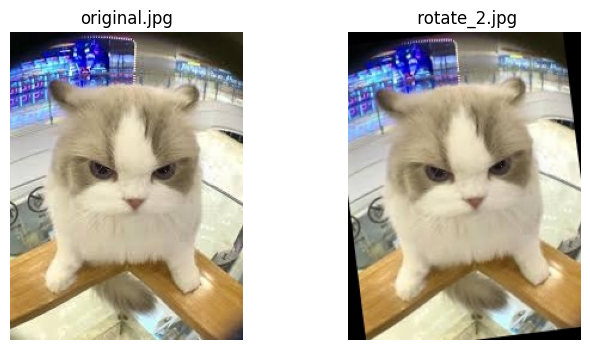

In [3]:

#Lấy một cặp ảnh giống nhau để hiển thị
img1, img2, name1, name2 = similar_pairs[9] 
img3, img4 ,name3, name4 = dissimilar_pairs[1]
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title(f"{name1}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title(f" {name2}")
plt.axis('off')
plt.show()


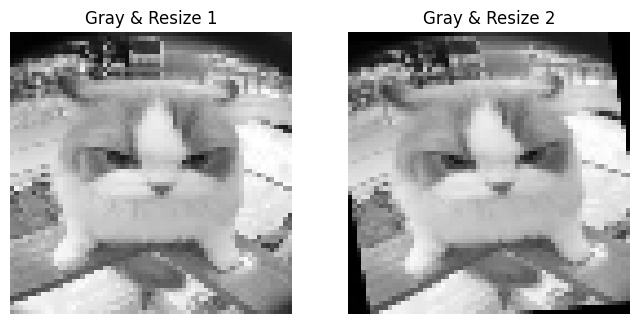

In [4]:
#Chuyển ảnh sang grayscale và resize về (64, 64) để chuẩn bị cho bước tính hash
gray1 = cv2.resize(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), (64, 64))
gray2 = cv2.resize(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), (64, 64))

# Chuẩn hóa giá trị pixel về [0, 1]
gray1 = np.float32(gray1) / 255.0
gray2 = np.float32(gray2) / 255.0

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gray1, cmap='gray')
plt.title("Gray & Resize 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray2, cmap='gray')
plt.title("Gray & Resize 2")
plt.axis('off')
plt.show()



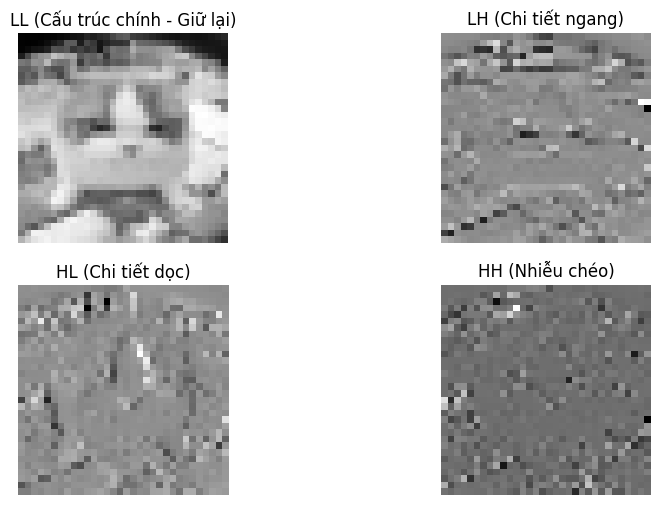

In [5]:
# "Biến đổi Wavelet giúp lọc sạch nhiễu, ta chỉ lấy dải tần số thấp LL – chứa cấu trúc cốt lõi của bức ảnh.
coeffs1 = pywt.wavedec2(gray1, 'haar', level=1)
LL1, (LH1, HL1, HH1) = coeffs1



plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.imshow(LL1, cmap='gray')
plt.title("LL (Cấu trúc chính - Giữ lại)")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(LH1, cmap='gray')
plt.title("LH (Chi tiết ngang)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(HL1, cmap='gray')
plt.title("HL (Chi tiết dọc)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(HH1, cmap='gray')
plt.title("HH (Nhiễu chéo)")
plt.axis('off')
plt.show()



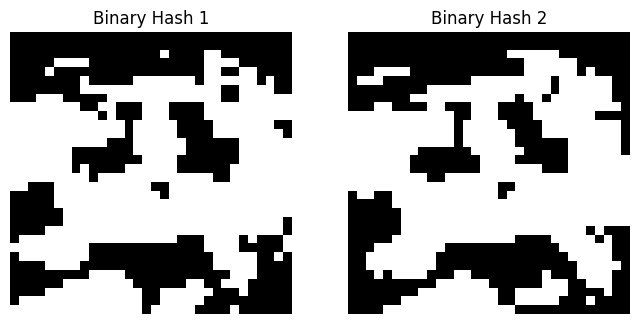

In [6]:
# Mỗi pixel trong vùng LL được so sánh với mức sáng trung bình để tạo thành một đoạn mã vạch đen trắng (0 và 1).

# Tính hash nhị phân từ LL
avg1 = np.mean(LL1)
hash1 = LL1 > avg1


coeffs2 = pywt.wavedec2(gray2, 'haar', level=1)
LL2, _ = coeffs2
avg2 = np.mean(LL2)
hash2 = LL2 > avg2

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(hash1, cmap='gray')
plt.title(f"Binary Hash 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hash2, cmap='gray')
plt.title(f"Binary Hash 2")
plt.axis('off')
plt.show()

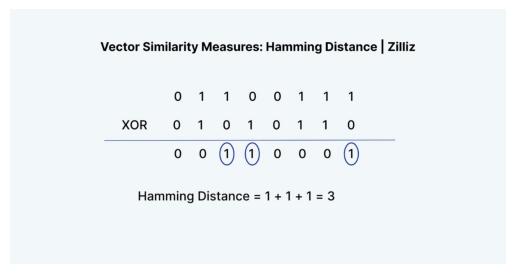

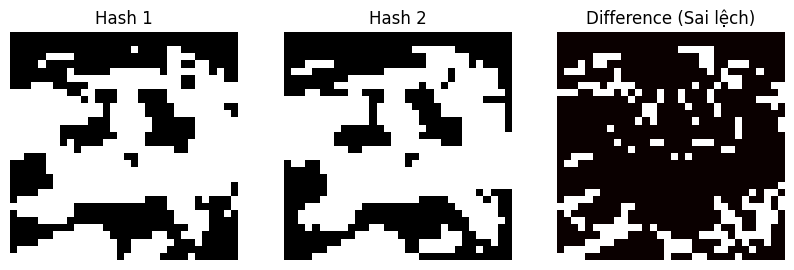

Điểm Hamming(Số bit khác nhau): 199


In [7]:
# So sánh hai hash và đếm số bit khác nhau để ra điểm Hamming. Điểm càng nhỏ thì ảnh càng giống nhau.
diff = hash1 != hash2
distance = np.count_nonzero(diff)   

img_2= cv2.imread('../wavelet/dataset/hamming.png')
img_rgb = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(hash1, cmap='gray')
plt.title("Hash 1")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hash2, cmap='gray')
plt.title("Hash 2")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(diff, cmap='hot')
plt.title(f"Difference (Sai lệch)")
plt.axis('off')
plt.show()

print(f"Điểm Hamming(Số bit khác nhau): {distance}")

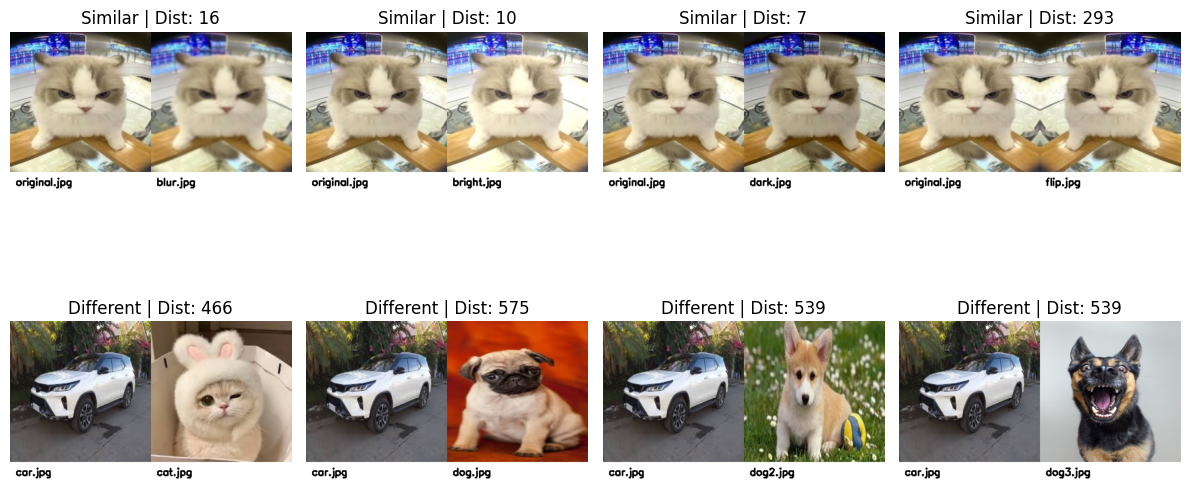

In [8]:
# Hàm hiển thị cặp ảnh giống nhau và khác nhau cùng với điểm Hamming
def show_sample_pairs(similar_pairs, dissimilar_pairs, num=4):
    plt.figure(figsize=(12, 7)) 
    num_sim = min(num, len(similar_pairs))
    num_diff = min(num, len(dissimilar_pairs))

    # Hàm phụ trợ để thêm tên ảnh vào dưới mỗi ảnh
    def add_text_below(img, text):
        img_resized = cv2.resize(img.copy(), (256, 256))
        canvas = np.ones((296, 256, 3), dtype=np.uint8) * 255
        canvas[0:256, 0:256] = img_resized
        cv2.putText(canvas, text, (10, 280), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
        return canvas
    # Hiển thị cặp ảnh giống nhau
    for i, (img1, img2, name1, name2) in enumerate(similar_pairs[:num_sim]):
        h1, h2 = wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)
        dist = get_hamming_distance(h1, h2)
        
        # Xử lý từng ảnh 
        disp_img1 = add_text_below(img1, name1)
        disp_img2 = add_text_below(img2, name2)
        
        plt.subplot(2, num, i + 1)
        plt.imshow(cv2.cvtColor(np.hstack((disp_img1, disp_img2)), cv2.COLOR_BGR2RGB))
        plt.title(f"Similar | Dist: {dist}")
        plt.axis('off')
    # Hiển thị cặp ảnh khác nhau
    for i, (img1, img2, name1, name2) in enumerate(dissimilar_pairs[:num_diff]):
        h1, h2 = wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)
        dist = get_hamming_distance(h1, h2)
        
        # Gọi hàm phụ trợ để xử lý từng ảnh
        disp_img1 = add_text_below(img1, name1)
        disp_img2 = add_text_below(img2, name2)
        
        plt.subplot(2, num, i + 1 + num)
        plt.imshow(cv2.cvtColor(np.hstack((disp_img1, disp_img2)), cv2.COLOR_BGR2RGB))
        plt.title(f"Different | Dist: {dist}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Gọi lại hàm
show_sample_pairs(similar_pairs, dissimilar_pairs)

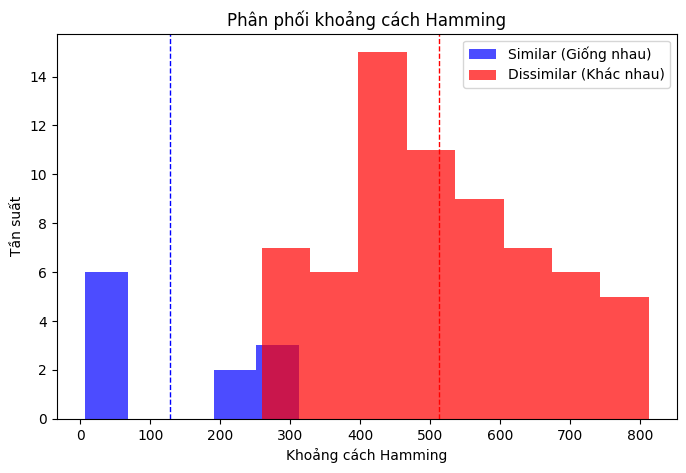

In [9]:
# Hàm vẽ histogram phân phối khoảng cách Hamming cho cặp ảnh giống nhau và khác nhau
def plot_distance_histogram(similar_pairs, dissimilar_pairs):
    #
    sim_dist = [get_hamming_distance(wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)) for img1, img2, _, _ in similar_pairs]
    diff_dist = [get_hamming_distance(wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)) for img1, img2, _, _ in dissimilar_pairs]

    plt.figure(figsize=(8, 5))
    plt.hist(sim_dist, bins='auto', alpha=0.7, label='Similar (Giống nhau)', color='blue')
    plt.hist(diff_dist, bins='auto', alpha=0.7, label='Dissimilar (Khác nhau)', color='red')
    # Vẽ đường trung bình
    plt.axvline(np.mean(sim_dist), color='blue', linestyle='dashed', linewidth=1)
    plt.axvline(np.mean(diff_dist), color='red', linestyle='dashed', linewidth=1)
    plt.legend()
    plt.title("Phân phối khoảng cách Hamming")
    plt.xlabel("Khoảng cách Hamming")
    plt.ylabel("Tần suất")
    plt.show()

plot_distance_histogram(similar_pairs, dissimilar_pairs)

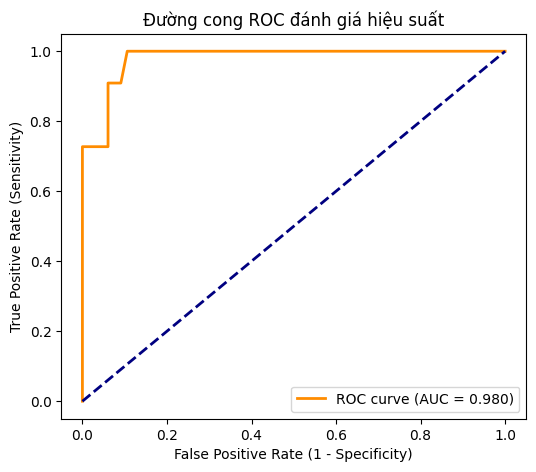

Ngưỡng tối ưu (Similarity Score): 0.6943
========== KẾT QUẢ ĐÁNH GIÁ TỔNG THỂ ==========
Tổng số cặp ảnh: 77 (11 giống, 66 khác)
Ngưỡng tối ưu (Similarity Score): 0.6943
-----------------------------------------------
1. Độ chính xác (Accuracy)    : 0.9091
2. Độ nhạy (Sensitivity)      : 1.0000
3. Độ đặc hiệu (Specificity)  : 0.8939


In [ ]:
# Hàm đánh giá hiệu suất 
def evaluate_performance(similar_pairs, dissimilar_pairs):
    # Tạo nhãn và tính khoảng cách Hamming cho tất cả cặp ảnh
    labels, distances = [], []
    for pairs, label in [(similar_pairs, 1), (dissimilar_pairs, 0)]:
        for img1, img2, name1, name2 in pairs:
            h1, h2 = wavelet_hash_pywt(img1), wavelet_hash_pywt(img2)
            distances.append(get_hamming_distance(h1, h2))
            labels.append(label)
    # Chuyển khoảng cách Hamming thành điểm tương đồng
    hash_len = len(wavelet_hash_pywt(np.zeros((64, 64))))
    scores = 1 - (np.array(distances) / hash_len)
    # Vẽ đường cong ROC và tính AUC
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Đường cong ROC đánh giá hiệu suất')
    plt.legend(loc="lower right")
    plt.show()
    
    # Tìm ngưỡng tối ưu
    idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[idx]   
    # best_thresh = 0.5
    preds = (scores >= best_thresh).astype(int) 
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    
    print(f"========== KẾT QUẢ ĐÁNH GIÁ TỔNG THỂ ==========")
    print(f"Tổng số cặp ảnh: {len(labels)} ({len(similar_pairs)} giống, {len(dissimilar_pairs)} khác)")
    print(f"Ngưỡng tối ưu (Similarity Score): {best_thresh:.4f}")
    print(f"-----------------------------------------------")
    print(f"1. Độ chính xác (Accuracy)    : {accuracy_score(labels, preds):.4f}")
    print(f"2. Độ nhạy (Sensitivity)      : {tp / (tp + fn):.4f}")
    print(f"3. Độ đặc hiệu (Specificity)  : {tn / (tn + fp):.4f}")

evaluate_performance(similar_pairs, dissimilar_pairs)

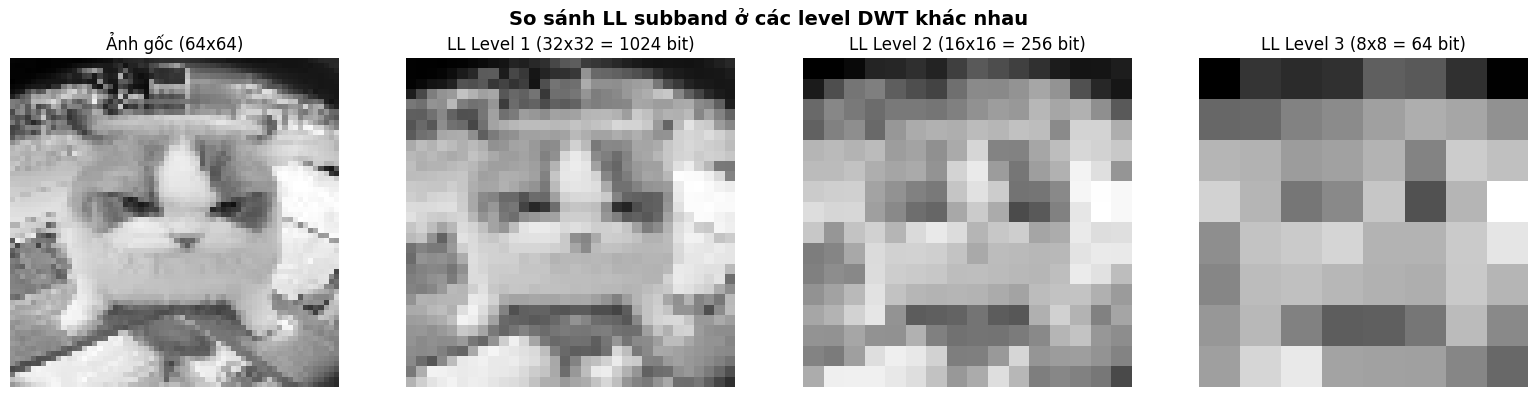

Level cao hơn -> LL nhỏ hơn -> hash compact hơn nhưng mất nhiều chi tiết hơn


In [ ]:

# SO SÁNH MULTI-LEVEL DWT (Level 1, 2, 3)

# Hàm wavelet hash hỗ trợ multi-level
def wavelet_hash_multilevel(image, size=(64, 64), wavelet='haar', level=1):
    """Tính wavelet hash với level DWT tùy chỉnh."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    gray = cv2.resize(gray, size)
    gray = np.float32(gray) / 255.0
    

    coeffs = pywt.wavedec2(gray, wavelet, level=level)
    LL = coeffs[0]
    avg = np.mean(LL)
    return (LL > avg).flatten()

# trực quan hóa ảnh gốc và LL ở các level DWT khác nhau
img_sample = similar_pairs[0][0]
gray_sample = cv2.resize(cv2.cvtColor(img_sample, cv2.COLOR_BGR2GRAY), (64, 64))
gray_sample = np.float32(gray_sample) / 255.0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Ảnh gốc grayscale
axes[0].imshow(gray_sample, cmap='gray')
axes[0].set_title("Ảnh gốc (64x64)")
axes[0].axis('off')

for i, lvl in enumerate([1, 2, 3]):
    coeffs = pywt.wavedec2(gray_sample, 'haar', level=lvl)
    LL = coeffs[0]
    axes[i+1].imshow(LL, cmap='gray')
    axes[i+1].set_title(f"LL Level {lvl} ({LL.shape[0]}x{LL.shape[1]} = {LL.size} bit)")
    axes[i+1].axis('off')

plt.suptitle("So sánh LL subband ở các level DWT khác nhau", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Level cao hơn -> LL nhỏ hơn -> hash compact hơn nhưng mất nhiều chi tiết hơn")

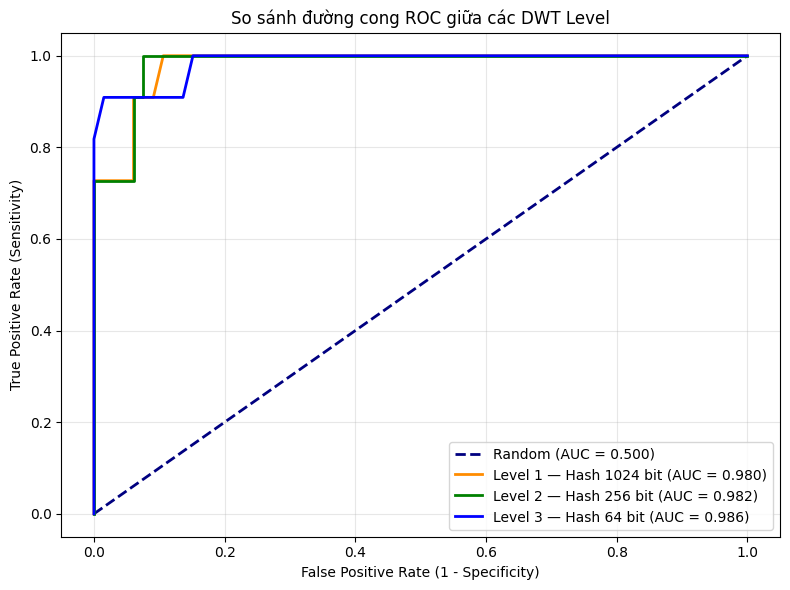

In [ ]:

from sklearn.metrics import f1_score, precision_score, recall_score

levels = [1, 2, 3]
colors = ['darkorange', 'green', 'blue']
results_table = []

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')

for lvl, color in zip(levels, colors):
    labels, distances = [], []
    for pairs, label in [(similar_pairs, 1), (dissimilar_pairs, 0)]:
        for img1, img2, _, _ in pairs:
            h1 = wavelet_hash_multilevel(img1, level=lvl)
            h2 = wavelet_hash_multilevel(img2, level=lvl)
            distances.append(get_hamming_distance(h1, h2))
            labels.append(label)

    hash_len = len(wavelet_hash_multilevel(np.zeros((64, 64), dtype=np.uint8), level=lvl))
    # Chuyển khoảng cách Hamming thành điểm tương đồng
    scores = 1 - (np.array(distances) / hash_len)

    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    # Vẽ đường ROC
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'Level {lvl} — Hash {hash_len} bit (AUC = {roc_auc:.3f})')

    # Tìm ngưỡng tối ưu 
    idx = np.argmax(tpr - fpr) 
    best_thresh = thresholds[idx]
    preds = (scores >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel() 

    results_table.append({
        'Level': lvl,
        'Hash size (bit)': hash_len,
        'AUC': round(roc_auc, 4),
        'Ngưỡng tối ưu': round(best_thresh, 4),
        'Accuracy': round(accuracy_score(labels, preds), 4),
        'Sensitivity': round(tp / (tp + fn), 4),
        'Specificity': round(tn / (tn + fp), 4),
        'F1-score': round(f1_score(labels, preds), 4),
    })

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('So sánh đường cong ROC giữa các DWT Level')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# --- Bảng tổng hợp so sánh metrics giữa các DWT Level ---
import pandas as pd

df_results = pd.DataFrame(results_table)
df_results = df_results.set_index('Level')

print("=" * 70)
print("       BẢNG SO SÁNH HIỆU SUẤT GIỮA CÁC DWT LEVEL")
print("=" * 70)
print(df_results.to_string())
print("=" * 70)

# Tìm level tốt nhất theo AUC
best_level = df_results['AUC'].idxmax()
print(f"\n>> Level tốt nhất theo AUC: Level {best_level} (AUC = {df_results.loc[best_level, 'AUC']})")
print(f"\nNhận xét:")
print(f"  - Level 1: Hash 1024 bit (32x32) — giữ nhiều chi tiết nhất, phân biệt tốt các biến thể nhỏ")
print(f"  - Level 2: Hash 256 bit (16x16) — cân bằng giữa compact và chi tiết")
print(f"  - Level 3: Hash 64 bit (8x8) — rất compact, tốc độ so sánh nhanh nhưng có thể mất chi tiết quan trọng")

       BẢNG SO SÁNH HIỆU SUẤT GIỮA CÁC DWT LEVEL
       Hash size (bit)     AUC  Ngưỡng tối ưu  Accuracy  Sensitivity  Specificity  F1-score
Level                                                                                      
1                 1024  0.9800         0.6943    0.9091       1.0000       0.8939    0.7586
2                  256  0.9821         0.7109    0.9351       1.0000       0.9242    0.8148
3                   64  0.9862         0.7969    0.9740       0.9091       0.9848    0.9091

>> Level tốt nhất theo AUC: Level 3 (AUC = 0.9862)

Nhận xét:
  - Level 1: Hash 1024 bit (32x32) — giữ nhiều chi tiết nhất, phân biệt tốt các biến thể nhỏ
  - Level 2: Hash 256 bit (16x16) — cân bằng giữa compact và chi tiết
  - Level 3: Hash 64 bit (8x8) — rất compact, tốc độ so sánh nhanh nhưng có thể mất chi tiết quan trọng
